In [1]:

import os
import sys
from pathlib import Path

# Add repo root and backend to import path.
REPO_ROOT = Path.cwd()
if (REPO_ROOT / "backend").exists():
    sys.path.insert(0, str(REPO_ROOT))
    sys.path.insert(0, str(REPO_ROOT / "backend"))



In [4]:
%pip install numpy opencv-python 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
%pip uninstall -y opencv-python numpy

Note: you may need to restart the kernel to use updated packages.


In [9]:
%pip install numpy==1.21.0 opencv-python==4.5.3.56

     ---------------------------------------- 0.0/10.3 MB ? eta -:--:--
     ---- ----------------------------------- 1.0/10.3 MB 7.8 MB/s eta 0:00:02
     -------- ------------------------------- 2.1/10.3 MB 5.5 MB/s eta 0:00:02
     ------------ --------------------------- 3.1/10.3 MB 5.3 MB/s eta 0:00:02
     ---------------- ----------------------- 4.2/10.3 MB 6.4 MB/s eta 0:00:01
     -------------------- ------------------- 5.2/10.3 MB 6.0 MB/s eta 0:00:01
     ------------------------ --------------- 6.3/10.3 MB 5.8 MB/s eta 0:00:01
     ---------------------------- ----------- 7.3/10.3 MB 5.7 MB/s eta 0:00:01
     -------------------------------- ------- 8.4/10.3 MB 5.6 MB/s eta 0:00:01
     ---------------------------------------- 10.3/10.3 MB 5.6 MB/s  0:00:01
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
Not


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Exception:
Traceback (most recent call last):
  File "c:\Users\Mrudula Rahate\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_internal\cli\base_command.py", line 107, in _run_wrapper
    status = _inner_run()
  File "c:\Users\Mrudula Rahate\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_internal\cli\base_command.py", line 98, in _inner_run
    return self.run(options, args)
           ~~~~~~~~^^^^^^^^^^^^^^^
  File "c:\Users\Mrudula Rahate\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_internal\cli\req_command.py", line 85, in wrapper
    return func(self, options, args)
  File "c:\Users\Mrudula Rahate\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_internal\commands\install.py", line 388, in run
    requirement_set = resolver.resolve(
        reqs, check_supported_wheels=not options.target_dir


In [7]:
import numpy as np
import cv2

RuntimeError: module compiled against ABI version 0x1000009 but this version of numpy is 0x2000000

ImportError: numpy.core.multiarray failed to import

In [13]:
from backend.pipeline.graph import build_graph
from backend.pipeline.nodes.ingest import ingest_pdf
from backend.pipeline.state import PipelineState
from backend.utils import pdf_utils

In [14]:
try:
    from dotenv import load_dotenv

    load_dotenv("backend/.env")
except Exception:
    pass

required_env = [
    "GOOGLE_CLOUD_PROJECT",
    "GCS_BUCKET_NAME",
    "DOCUMENT_AI_PROCESSOR_ID",
    "DOCUMENT_AI_LOCATION",
]

missing = [key for key in required_env if not os.getenv(key)]
print("Missing env vars:", missing)
print("Project:", os.getenv("GOOGLE_CLOUD_PROJECT"))

Missing env vars: []
Project: project-953fdbff-8291-4198-9c5


In [ ]:
from urllib.parse import urlparse

PDF_PATH = "file:///D:/Mrudula/PersonalProject/DocumentIntelligenceAgent/Engineering_Drawing_Intelligence_Agent/raw_data/D00182948_A.pdf"
#PDF_PATH = "file:///D:/Mrudula/PersonalProject/DocumentIntelligenceAgent/Engineering_Drawing_Intelligence_Agent/raw_data/D01329027_C.PDF"


def _normalize_path(path: str) -> Path:
    if path.startswith("file://"):
        parsed = urlparse(path)
        return Path(parsed.path.lstrip("/"))
    return Path(path)


pdf_path = _normalize_path(PDF_PATH)
print("PDF path:", pdf_path)
print("Exists:", pdf_path.exists())

PDF path: D:\Mrudula\PersonalProject\DocumentIntelligenceAgent\Engineering_Drawing_Intelligence_Agent\raw_data\D00122284.pdf
Exists: True


In [101]:
import importlib

importlib.reload(pdf_utils)

pdf_bytes = pdf_path.read_bytes()
page_images = pdf_utils.rasterize_pdf(pdf_bytes, dpi=300)
raw_text_blocks = pdf_utils.extract_text_blocks(pdf_bytes)
raw_drawings = pdf_utils.extract_vector_drawings(pdf_bytes)

state: PipelineState = {
    "pdf_gcs_path": "",
    "job_id": "local-debug",
    "drawing_id": "local-drawing",
    "page_images": page_images,
    "raw_text_blocks": raw_text_blocks,
    "raw_drawings": raw_drawings,
    "bom_result": None,
    "notes_result": None,
    "title_result": None,
    "drawing_result": None,
    "errors": {},
    "final_json": None,
    "ingest_result": None,
    "store_result": None,
}

print("Pages:", len(page_images))
print("Text blocks:", len(raw_text_blocks))
print("Vector pages:", len(raw_drawings))

Pages: 1
Text blocks: 0
Vector pages: 1


In [94]:
#%pip install easyocr

Page 0: 2 tables found
  Table 1: (124, 47) to (3160, 349), size: 3036x302
  Table 2: (2636, 2802) to (5079, 3066), size: 2443x264


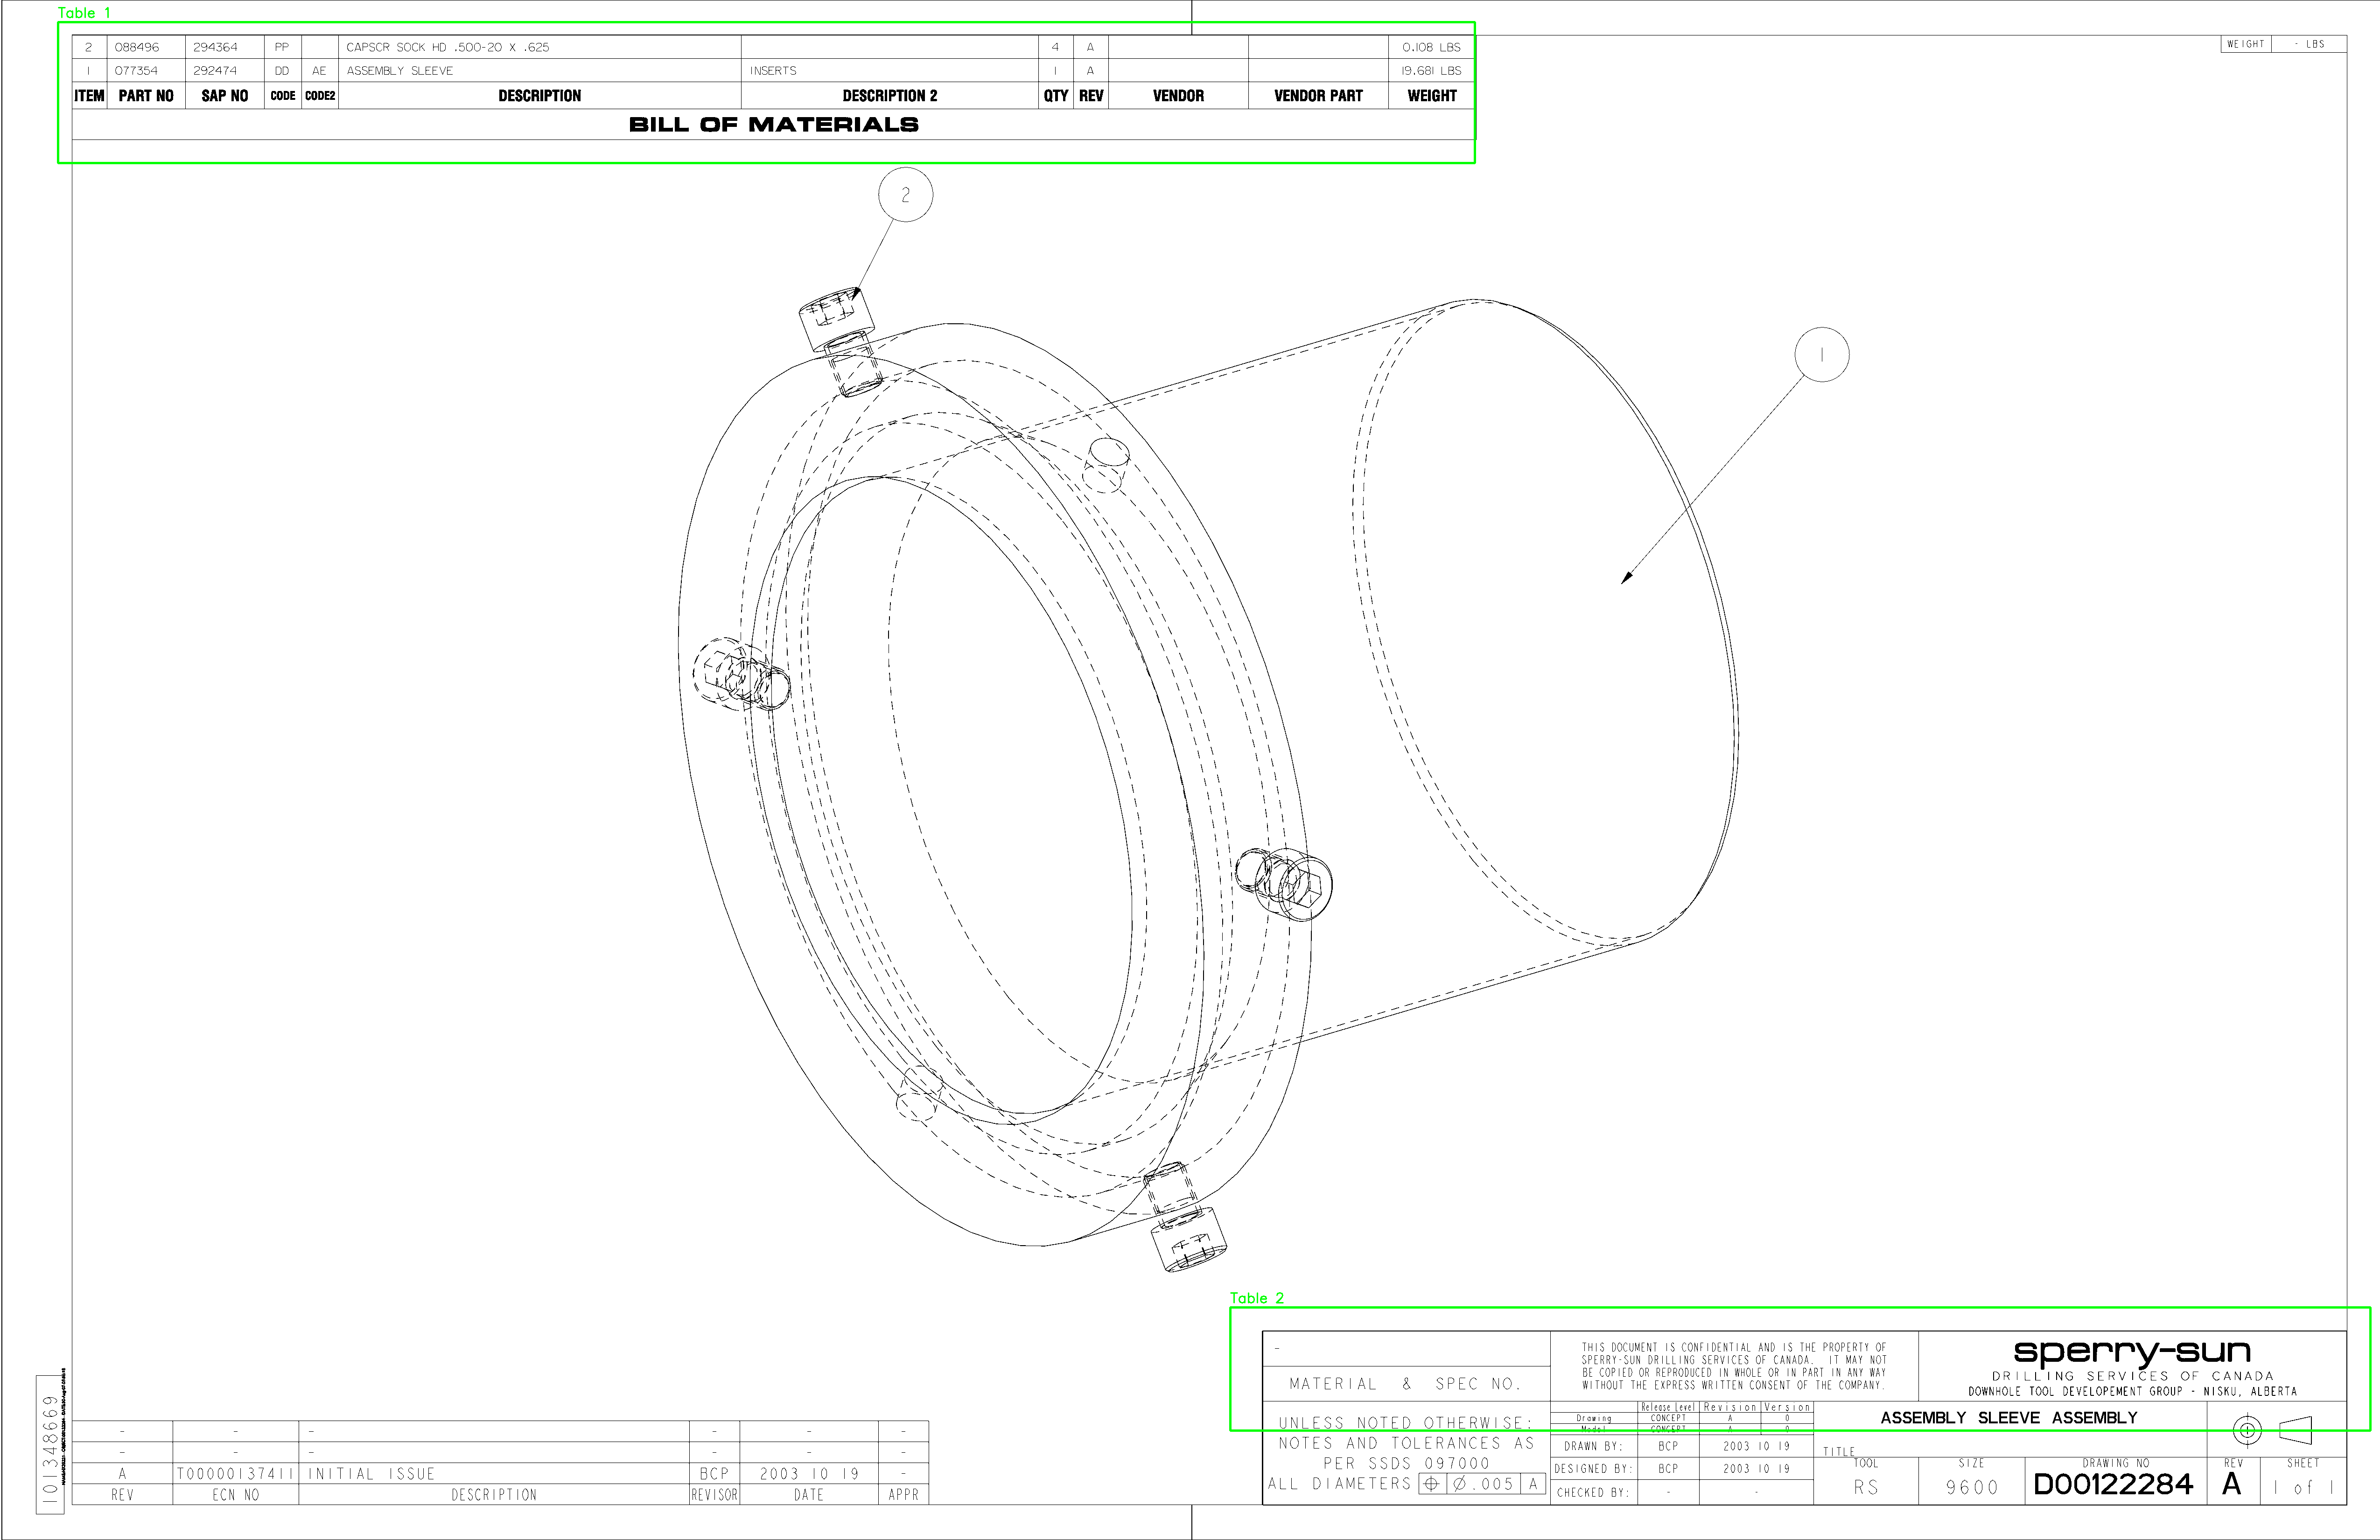

In [102]:
import pdfplumber
import cv2
import numpy as np
from PIL import Image

with pdfplumber.open(pdf_path) as pdf:
    for page_num, page in enumerate(pdf.pages):
        img = page.to_image(resolution=300).original
        img_cv = cv2.cvtColor(np.array(img.convert('RGB')), cv2.COLOR_RGB2BGR)
        
        # Use valid strategy names
        table_settings = {
            "vertical_strategy": "lines",
            "horizontal_strategy": "lines",
            "intersection_tolerance": 5
        }
        
        tables = page.extract_tables(table_settings=table_settings)
        bounds = page.find_tables(table_settings=table_settings)
        
        print(f"Page {page_num}: {len(tables)} tables found")
        padding = 50 
        scale = 300 / 72
        for table_idx, table in enumerate(tables):
            bbox = bounds[table_idx].bbox
            if bbox:
                x1, y1, x2, y2 = bbox
                x1, y1, x2, y2 = int(x1 * scale) - padding, int(y1 * scale) - padding, int(x2 * scale) + padding, int(y2 * scale) + padding
                
                # Filter by minimum size
                width = x2 - x1
                height = y2 - y1
                
                if width >= 2000 and height >= 200:
                    cv2.rectangle(img_cv, (x1, y1), (x2, y2), (0, 255, 0), 3)
                    cv2.putText(img_cv, f"Table {table_idx + 1}", (x1, y1 - 10),
                               cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
                    print(f"  Table {table_idx + 1}: ({x1}, {y1}) to ({x2}, {y2}), size: {width}x{height}")
        
        display(Image.fromarray(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)))

In [117]:
import pdfplumber
import cv2
import numpy as np
from PIL import Image
import json
import io

def extract_table_contents(pdf_path, min_width=2000, min_height=200, padding=50, dpi=300):
    """Extract table contents from PDF and return as JSON."""
    results = []
    
    with pdfplumber.open(pdf_path) as pdf:
        for page_num, page in enumerate(pdf.pages):
            table_settings = {
                "vertical_strategy": "lines",
                "horizontal_strategy": "lines",
                "intersection_tolerance": 5
            }
            
            tables = page.extract_tables(table_settings=table_settings)
            bounds = page.find_tables(table_settings=table_settings)
            
            scale = dpi / 72
            
            for table_idx, table in enumerate(tables):
                bbox = bounds[table_idx].bbox
                if not bbox:
                    continue
                
                x1, y1, x2, y2 = bbox
                x1, y1, x2, y2 = int(x1 * scale) - padding, int(y1 * scale) - padding, int(x2 * scale) + padding, int(y2 * scale) + padding
                
                width = x2 - x1
                height = y2 - y1
                
                if width >= min_width and height >= min_height:
                    table_data = {
                        "page": page_num + 1,
                        "table_index": table_idx + 1,
                        "bbox": {"x1": x1, "y1": y1, "x2": x2, "y2": y2},
                        "dimensions": {"width": width, "height": height},
                        "rows": []
                    }
                    
                    # Process table rows
                    for row in table:
                        # Filter out None/empty cells
                        cleaned_row = [cell.strip() if cell and isinstance(cell, str) else "" for cell in row]
                        if any(cleaned_row):  # Only add non-empty rows
                            table_data["rows"].append(cleaned_row)
                    
                    results.append(table_data)
    
    return results

def ocr_region(img_cv, x1, y1, x2, y2):
    """Extract text from a specific region using pixel-based approach."""
    # Crop region
    roi = img_cv[y1:y2, x1:x2]
    
    # Convert to grayscale
    gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    
    # Use pytesseract for OCR if available, else return structured text
    try:
        import pytesseract
        text = pytesseract.image_to_string(gray)
        return text
    except ImportError:
        return None

# Usage
table_data = extract_table_contents(pdf_path)
print(json.dumps(table_data, indent=2))

# Save to JSON file
with open("extracted_tables.json", "w") as f:
    json.dump(table_data, f, indent=2)

print(f"\nExtracted {len(table_data)} tables")

[
  {
    "page": 1,
    "table_index": 1,
    "bbox": {
      "x1": 124,
      "y1": 47,
      "x2": 3160,
      "y2": 349
    },
    "dimensions": {
      "width": 3036,
      "height": 302
    },
    "rows": []
  },
  {
    "page": 1,
    "table_index": 2,
    "bbox": {
      "x1": 2636,
      "y1": 2802,
      "x2": 5079,
      "y2": 3066
    },
    "dimensions": {
      "width": 2443,
      "height": 264
    },
    "rows": []
  }
]

Extracted 2 tables


In [1]:
print(gray)

NameError: name 'gray' is not defined

In [118]:
table = table_data[0]
x1, y1, x2, y2 = table['bbox']['x1'], table['bbox']['y1'], table['bbox']['x2'], table['bbox']['y2']

# Load PDF page image
with pdfplumber.open(pdf_path) as pdf:
    page = pdf.pages[table['page'] - 1]
    img = page.to_image(resolution=300).original
    img_cv = cv2.cvtColor(np.array(img.convert('RGB')), cv2.COLOR_RGB2BGR)

# Test OCR on the region
text = ocr_region(img_cv, x1, y1, x2, y2)
print(text)

2 | 088496 294364 PP CAPSCR SOCK HD .500-20 X .625 4 | A 0.108 LBS
| | 077354 292474 oD | AE | ASSEMBLY SLEEVE INSERTS i | a 9.681 LBS
ITEM| PARTNO | SAP NO | cope | copEz DESCRIPTION DESCRIPTION 2 QTY | REV VENDOR VENDOR PART WEIGHT

BILL OF MATERIALS


